In [9]:
import json
import torch

from player_encoder_infine.dataset import MetaStyleDataset
from player_encoder_infine.encoder import TransformerEncoder

from torch.utils.data import DataLoader
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
def unpack_batch(batch):
    return (
        batch['support_pos'].to(device),
        batch['support_mask'].to(device),
        batch['support_labels'].to(device),
        batch['query_pos'].to(device),
        batch['query_mask'].to(device),
        batch['query_labels'].to(device)
    )

def plot_data(within_players, between_players, self_non, self_query, non_self_query, title, data_num):
    plt.figure(figsize=(6, 4))
    plt.hist(within_players.cpu(), bins=30, density=True, alpha=0.5, color='C0', label="within players (vector vs prototype)")
    plt.hist(between_players.cpu(), bins=30, density=True, alpha=0.5, color='C1', label="between players (prototype vs prototype)")
    plt.hist(self_non.cpu(), bins=30, density=True, alpha=0.5, color='C2', label="between self and non-self (vector vs prototype)")
    plt.hist(self_query.cpu(), bins=30, density=True, alpha=0.5, color='C3', label="between self and self query (vector vs vector)")
    plt.hist(non_self_query.cpu(), bins=30, density=True, alpha=0.5, color='C4', label="between self and non-self query (vector vs vector)")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Density")
    plt.title(f"Similarity Distribution - {title} - {data_num}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def load_dataset_file(path):
    with open(f"./chess_data_parse/{path}.json", "r", encoding="utf-8") as f:
        return json.load(f)

In [11]:
encoder = TransformerEncoder(cnn_in_channels=224, state_embed_dim=256, transformer_d_model=256,
                                        num_heads=8, num_layers=3, dropout=0.1).to(device)

d = torch.load('./models/trained_model/player_encoder_58.pt')
encoder.load_state_dict(d["model_state_dict"])

N = 5
K = 5
Q = 5

test_dataset = MetaStyleDataset(load_dataset_file("test_players"), 60, rand=False, N=N, K=K, Q=Q)

train_dataset = MetaStyleDataset(load_dataset_file("train_players"), 2300 // 5, rand=False, N=N, K=K, Q=Q)

In [12]:
def build_prototypes_from_support(data):
    prototypes = []
    labels = []
    support_games = data['support']['games'].to(device)
    support_masks = data['support']['masks'].to(device)

    with torch.autocast(device_type="cuda"):
        _, support_z = encoder(support_games, support_masks)
    support_z = support_z.view(N, K, -1)  # [N, K, d]
    prototypes = support_z.mean(dim=1)  # [N, d]
    return prototypes

from torch.nn.utils.rnn import pad_sequence
def collate_fn(sample):
    # 这里的 batch 是一个列表，包含了多个样本
    # 你可以根据需要进行处理，比如将它们拼接成一个大的 tensor

    splits = ('support', 'query')
    batched = {}

    # batch_size = len(batch)

    for split in splits:
        # 收集这一 split 下所有样本的 game/mask
        all_games = []
        all_masks = []
        all_games.extend(sample[split]['games']) # [N, T, C, H, W]
        all_masks.extend(sample[split]['masks'])

        # 对所有序列进行统一 padding
        # padded_games: [batch_size*K_or_Q, T_max, ...]
        padded_games = pad_sequence(all_games, batch_first=True)
        # padded_masks: [batch_size*K_or_Q, T_max]
        padded_masks = pad_sequence(all_masks, batch_first=True, padding_value=True)

        # [batch_size, K_or_Q, T_max, ...]
        padded_games = padded_games.view(1, padded_games.size(0) // 1, *padded_games.size()[1:])
        # [batch_size, K_or_Q, T_max]   
        padded_masks = padded_masks.view(1, padded_masks.size(0) // 1, *padded_masks.size()[1:])

        # 将拼接好的 tensor 放入 batched 字典中
        batched[split] = {
            'games': padded_games,
            'masks': padded_masks,
            'len': padded_games.size(1)  # K_or_Q
        }

    return batched

@torch.no_grad()
def test(dataset):
    all_prototypes = []
    all_query_z = []
    for idx, batch in enumerate(dataset):
        if idx >= len(dataset):
            break
        sample = collate_fn(batch)
        prototypes = build_prototypes_from_support(data=sample)
        prototypes = prototypes.squeeze(0)  # [1, N, d] -> [N, d]
        all_prototypes.append(prototypes)

        query_games = sample['query']['games'].to(device)  # [1, Q, T_max, C, H, W]
        query_masks = sample['query']['masks'].to(device)  # [1, Q, T_max]

        with torch.autocast(device_type="cuda"):
            _, query_z = encoder(query_games, query_masks) # [1, d]

        all_query_z.append(query_z.view(N, Q, -1))  # [1, Q, d]
            
    
    all_protos = torch.cat(all_prototypes, dim=0)  # [N, d]
    all_query_z = torch.cat(all_query_z, dim=0) # [N, Q, d]

    return all_protos, all_query_z

all_protos_train, all_query_z_train = test(train_dataset)
all_protos_test, all_query_z_test = test(test_dataset)

print(all_protos_train.shape, all_query_z_train.shape)
print(all_protos_test.shape, all_query_z_test.shape)


torch.Size([2300, 256]) torch.Size([2300, 5, 256])
torch.Size([300, 256]) torch.Size([300, 5, 256])


torch.Size([2300, 256]) torch.Size([2300, 5, 256])
Train set accuracy: 0.1250


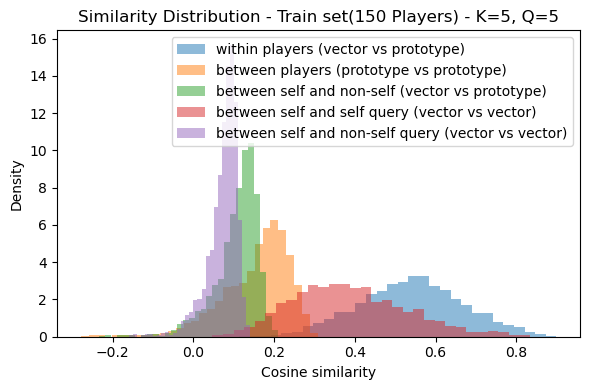

Test set accuracy: 0.0927


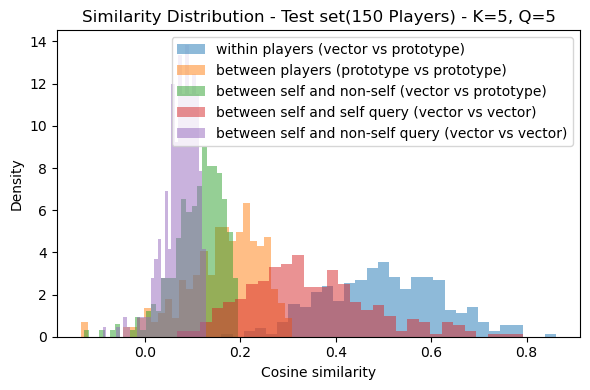

In [18]:
def sim_between_players(all_protos):
    # 1. L2 归一化
    normed = F.normalize(all_protos, dim=1)            # [N, D]
    # 2. 相似度矩阵
    sim_matrix = normed @ normed.T                     # [N, N]
    # 3. 将对角线（self-sim）设为 0
    sim_matrix.fill_diagonal_(0.0)
    # 4. 对每一行求和，再除以 (N-1) 就是该 proto 与其他所有 proto 的平均相似度
    avg_sims = sim_matrix.sum(dim=1) / (all_protos.size(0) - 1)  # [N]
    return avg_sims

def sim_between_self(all_protos, query_z):
    # all_protos: [N, d], query_z: [N, Q, d]
    # 1. L2 归一化
    normed_protos = F.normalize(all_protos, dim=1)    # [N, d]
    normed_query = F.normalize(query_z,     dim=2)    # [N, Q, d]

    # 2. 计算每个 player 自身 prototype 与每条 query 的余弦相似度
    #    扩展 prototype 维度为 [N, 1, d]，与 [N, Q, d] 对齐，再做点积求和
    protos_exp   = normed_protos.unsqueeze(1)         # [N, 1, d]
    cos_sims     = (protos_exp * normed_query).sum(dim=2)  # [N, Q]

    # 3. 对 Q 条相似度取平均
    avg_self_sims = cos_sims.mean(dim=1)              # [N]
    return avg_self_sims

def avg_query_pairwise_sim(query_z):
    """
    query_z: Tensor of shape [N, Q, d]
    返回 avg_sims: Tensor of shape [N], 表示每个玩家 Q 条 query 两两之间的平均余弦相似度
    """
    N, Q, d = query_z.shape

    # 1. L2 归一化
    normed = F.normalize(query_z, dim=2)          # [N, Q, d]

    # 2. 相似度矩阵：对每个玩家，Q×d @ d×Q -> Q×Q
    #    sim_matrix[n,i,j] = cos(query_z[n,i], query_z[n,j])
    sim_matrix = torch.matmul(normed, normed.transpose(1, 2))  # [N, Q, Q]

    # 3. 去掉对角线（自身与自身的 similarity=1）
    #    我们要的平均是所有 i≠j 对
    #    一共有 Q*(Q-1) 个（有向对，如果只算无序对则是 Q*(Q-1)/2，但最终结果相同）
    sim_matrix = sim_matrix - torch.eye(Q, device=sim_matrix.device).unsqueeze(0)

    # 4. 求和并除以对数
    sum_off_diag = sim_matrix.sum(dim=(1, 2))            # [N], 总和已去掉了 Q 个 1
    avg_sims = sum_off_diag / (Q * (Q - 1))              # [N]

    return avg_sims


def avg_query_vs_nonself_proto_sim(all_protos, query_z):
    """
    all_protos: Tensor of shape [N, d]
    query_z:    Tensor of shape [N, Q, d]
    返回: Tensor of shape [N], 表示每个 player 的 Q 条 query 与其他 players prototype 平均相似度
    """
    N, d = all_protos.shape
    Q = query_z.size(1)

    # 1. L2 归一化
    normed_protos = F.normalize(all_protos, dim=1)     # [N, d]
    normed_query  = F.normalize(query_z,     dim=2)    # [N, Q, d]

    # 2. 计算 [N, Q, N] 的相似度张量：每个 player 的每条 query 与所有 N 个 prototype
    #    利用广播 matmul： [N, Q, d] @ [d, N] -> [N, Q, N]
    sims = torch.matmul(normed_query, normed_protos.T)  # [N, Q, N]

    # 3. 掩掉“自己”的那一列（i,i）：mask 形状为 [N,1,N]
    mask = torch.eye(N, device=sims.device, dtype=torch.bool)  # [N, N]
    sims = sims.masked_fill(mask.unsqueeze(1), 0.0)

    # 4. 对剩余 (N-1)*Q 个值求平均
    sum_sims = sims.sum(dim=(1, 2))  # [N], 每个玩家的相似度总和
    avg_sims = sum_sims / ((N - 1) * Q)

    return avg_sims  # [N]

def avg_query_vs_nonself_query_sim(query_z: torch.Tensor) -> torch.Tensor:
    """
    计算每个玩家的 Q 条 query 与所有其他玩家的 query 的平均余弦相似度。

    Args:
        query_z: Tensor of shape [N, Q, d]

    Returns:
        avg_sims: Tensor of shape [N], 每个玩家所有 query 与非自己的 query 的平均相似度
    """
    N, Q, d = query_z.shape

    # 1. L2 归一化
    normed = F.normalize(query_z, dim=2)            # [N, Q, d]

    # 2. 展平所有 query 到一个维度
    flat = normed.view(N * Q, d)                    # [N*Q, d]

    # 3. 计算全局相似度矩阵
    sim_full = torch.matmul(flat, flat.T)           # [N*Q, N*Q]

    # 4. 掩掉“同一玩家内部”的 Q×Q 块
    #    构造 mask，将第 i 个玩家的 query block 置为 True
    device = sim_full.device
    mask = torch.zeros_like(sim_full, dtype=torch.bool, device=device)
    for i in range(N):
        start = i * Q
        end   = (i + 1) * Q
        mask[start:end, start:end] = True
    sim_full = sim_full.masked_fill(mask, 0.0)

    # 5. 对每个玩家 i，取它的 Q 条 query（第 i*Q:(i+1)*Q 行）与所有非自己 query 的相似度总和
    sim_player_sum = (
        sim_full
        .view(N, Q, N * Q)   # 分组：N 个玩家，每组 Q 行
        .sum(dim=(1, 2))     # 对每组的 Q×(N*Q) 矩阵求和
    )  # [N]

    # 6. 计算平均：每个玩家有 Q*(N-1)*Q 个非自己 pairs
    denom = Q * (N - 1) * Q
    avg_sims = sim_player_sum / denom  # [N]

    return avg_sims

@torch.no_grad()
def calc_query_z_class_accuracy(all_protos: torch.Tensor,
                                 query_z: torch.Tensor) -> torch.Tensor:
    """
    计算每个 player 的 Q 条 query 的分类准确率。

    Args:
        all_protos: Tensor of shape [N, d], N 个 prototype
        query_z:    Tensor of shape [N, Q, d], 每个 player 的 Q 条 query

    Returns:
        accuracies: Tensor of shape [N], 每个 player 的准确率 = (预测正确数 / Q)
    """
    _, d = all_protos.shape
    N, Q, d = query_z.size()

    # 1. L2 归一化
    protos_norm = F.normalize(all_protos, dim=1)       # [N, d]
    queries_norm = F.normalize(query_z, dim=2)         # [N, Q, d]

    # 2. 展平所有 query 并计算相似度
    queries_flat = queries_norm.view(-1, d)         # [N*Q, d]
    sims = torch.matmul(queries_flat, protos_norm.T)   # [N*Q, N]

    # 3. 预测标签：取相似度最高的 prototype 下标
    preds = sims.argmax(dim=1)                         # [N*Q]

    # 4. 构造真实标签：第 i 个 player 的 Q 条 query 的标签都是 i
    true_labels = torch.arange(N, device=all_protos.device) \
                      .repeat_interleave(Q)           # [N*Q]

    # 5. 计算每条 query 的是否预测正确
    correct = (preds == true_labels).view(N, Q)        # [N, Q], bool

    # 6. 计算每个 player 的准确率
    accuracies = correct.float().mean(dim=1)           # [N]

    return accuracies

print(all_protos_train.shape, all_query_z_train.shape)
from torch.nn import functional as F

F.normalize(all_protos_train, dim=-1)
F.normalize(all_query_z_train, dim=-1)

F.normalize(all_protos_test, dim=-1)
F.normalize(all_query_z_test, dim=-1)

avg_sims_between_players = sim_between_players(all_protos_train)
avg_between_self = sim_between_self(all_protos_train, all_query_z_train)
avg_self_non_self_proto = avg_query_vs_nonself_proto_sim(all_protos_train, all_query_z_train)
avg_query_pairwise = avg_query_pairwise_sim(all_query_z_train)
avg_query_vs_nonself_query = avg_query_vs_nonself_query_sim(all_query_z_train)

accuracies = calc_query_z_class_accuracy(all_protos_train, all_query_z_train)
print(f"Train set accuracy: {accuracies.mean().item():.4f}")

plot_data(avg_between_self, avg_sims_between_players, avg_self_non_self_proto, avg_query_pairwise, avg_query_vs_nonself_query, "Train set(150 Players)", f"K={K}, Q={Q}")

avg_sims_between_players = sim_between_players(all_protos_test)
avg_between_self = sim_between_self(all_protos_test, all_query_z_test)
avg_self_non_self_proto = avg_query_vs_nonself_proto_sim(all_protos_test, all_query_z_test)
avg_query_pairwise = avg_query_pairwise_sim(all_query_z_test)
avg_query_vs_nonself_query = avg_query_vs_nonself_query_sim(all_query_z_test)

accuracies = calc_query_z_class_accuracy(torch.cat([all_protos_test,all_protos_train]), all_query_z_test)
print(f"Test set accuracy: {accuracies.mean().item():.4f}")

plot_data(avg_between_self, avg_sims_between_players, avg_self_non_self_proto, avg_query_pairwise, avg_query_vs_nonself_query, "Test set(150 Players)", f"K={K}, Q={Q}")

C:\Users\JOU\AppData\Local\Temp\ipykernel_22680\1342320646.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', N)


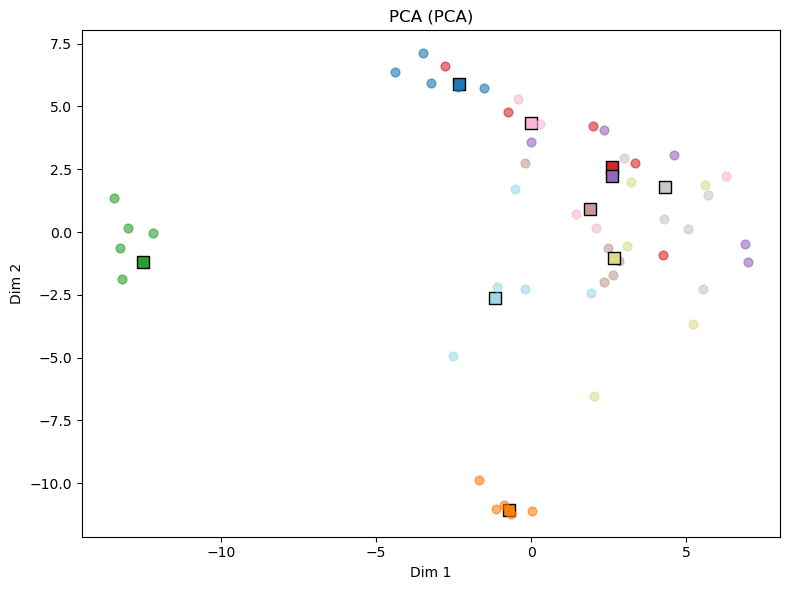

C:\Users\JOU\AppData\Local\Temp\ipykernel_22680\1342320646.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', N)


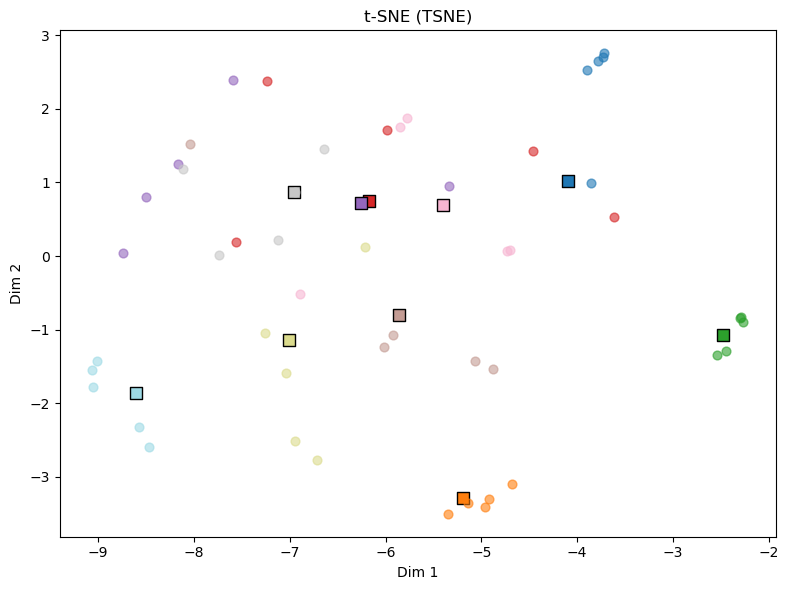

In [14]:

def embed_and_plot(
    all_protos: torch.Tensor,
    all_query_z: torch.Tensor,
    method: str = 'pca',
    title: str = 'Embedding',
    tsne_perplexity: int = None
):
    """
    可视化原型和查询嵌入的 PCA 或 t-SNE 降维结果。
    all_protos:      [N, D] 原型张量
    all_query_z:     [N, Q, D] 查询嵌入张量
    method:          'pca' 或 'tsne'
    tsne_perplexity: 如果 method='tsne'，指定 perplexity；默认为 min(30, n_samples-1)
    """
    # 转 numpy
    protos_np  = all_protos.cpu().numpy()                             # [N, D]
    queries_np = all_query_z.cpu().numpy().reshape(-1, all_protos.size(1))  # [N*Q, D]
    N, D = protos_np.shape
    Q = all_query_z.size(1)

    # 合并
    data = np.vstack([protos_np, queries_np])  # [N + N*Q, D]

    # 选择降维器
    if method.lower() == 'pca':
        reducer = PCA(n_components=2)
    elif method.lower() == 'tsne':
        n_samples = data.shape[0]
        # perplexity 必须 < n_samples
        default_perp = min(30, n_samples - 1)
        perp = tsne_perplexity or default_perp
        if perp >= n_samples:
            raise ValueError(f"tsne_perplexity ({perp}) must be less than n_samples ({n_samples})")
        reducer = TSNE(n_components=2, perplexity=perp, random_state=42)
    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    # 降维
    emb2d = reducer.fit_transform(data)                # [N + N*Q, 2]

    # 拆分
    protos_2d  = emb2d[:N]                             # [N, 2]
    queries_2d = emb2d[N:].reshape(N, Q, 2)            # [N, Q, 2]

    # 绘图
    plt.figure(figsize=(8, 6))
    cmap = plt.cm.get_cmap('tab20', N)
    for i in range(N):
        # 原型：方形
        plt.scatter(
            protos_2d[i, 0], protos_2d[i, 1],
            marker='s', edgecolor='k', s=80, color=cmap(i)
        )
        # Query：圆形
        plt.scatter(
            queries_2d[i, :, 0], queries_2d[i, :, 1],
            marker='o', alpha=0.6, s=40, color=cmap(i)
        )

    plt.title(f'{title} ({method.upper()})')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.tight_layout()
    plt.show()

player_num = 10
embed_and_plot(all_protos_train[:player_num], all_query_z_train[:player_num], method='pca', title='PCA')
embed_and_plot(all_protos_train[:player_num], all_query_z_train[:player_num], method='tsne', title='t-SNE')

In [15]:

# print(f"Number of prototypes: {len(prototypes)}")
# print(f"Number of query embeddings: {all_query_embeddings.shape[0]}, {all_query_embeddings_labels.shape[0]}, {all_prototypes_labels.shape[0]}")

# num = 10
# start_idx = random.randint(0, int(len(all_query_embeddings) / 5 - 1))
# print("Start index:", start_idx, len(all_query_embeddings) / 5 - 1)

# filtered_query_embeddings = all_query_embeddings[start_idx * 5 : start_idx * 5 + num * 5].cpu()
# filtered_query_labels = all_query_embeddings_labels[start_idx * 5 : start_idx * 5 + num * 5].cpu()

# filtered_proto_embeddings = prototypes_tensor[start_idx : start_idx + num].cpu()
# filtered_proto_labels = all_prototypes_labels[start_idx : start_idx + num].cpu()

# unique_labels = torch.unique(torch.cat([filtered_query_labels, filtered_proto_labels], dim=0))
# print("Unique labels:", unique_labels)

# cmap = plt.get_cmap("tab10")
# color_dict = {label.item(): cmap(i) for i, label in enumerate(unique_labels)}

# combined_embeddings = torch.cat([filtered_query_embeddings, filtered_proto_embeddings], dim=0)
# num_query = filtered_query_embeddings.shape[0]  # query 的数量

# # ---------------------------
# # PCA
# # ---------------------------
# pca_result = PCA(n_components=2).fit_transform(combined_embeddings.numpy())

# plt.figure(figsize=(12, 9))
# plotted_labels = set()

# for label in unique_labels:
#     label_val = label.item()
#     query_indices = (filtered_query_labels == label_val).nonzero(as_tuple=True)[0].numpy()
#     proto_indices = (filtered_proto_labels == label_val).nonzero(as_tuple=True)[0].numpy() + num_query

#     label_query = f"Query {label_val}"
#     if label_query not in plotted_labels:
#         plt.scatter(pca_result[query_indices, 0],
#                     pca_result[query_indices, 1],
#                     color=color_dict[label_val],
#                     marker='o',
#                     label=label_query)
#         plotted_labels.add(label_query)
#     else:
#         plt.scatter(pca_result[query_indices, 0],
#                     pca_result[query_indices, 1],
#                     color=color_dict[label_val],
#                     marker='o')

#     label_proto = f"Prototype {label_val}"
#     if label_proto not in plotted_labels:
#         plt.scatter(pca_result[proto_indices, 0],
#                     pca_result[proto_indices, 1],
#                     color=color_dict[label_val],
#                     marker='s',
#                     label=label_proto)
#         plotted_labels.add(label_proto)
#     else:
#         plt.scatter(pca_result[proto_indices, 0],
#                     pca_result[proto_indices, 1],
#                     color=color_dict[label_val],
#                     marker='s')

# plt.legend()
# plt.title(f"PCA: {num} players, K=5, Q=5")
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
# plt.show()

# # ---------------------------
# # t-SNE
# # ---------------------------
# tsne_result = TSNE(n_components=2, perplexity=20).fit_transform(combined_embeddings.numpy())

# plt.figure(figsize=(12, 9))
# plotted_labels = set()

# for label in unique_labels:
#     label_val = label.item()
#     query_indices = (filtered_query_labels == label_val).nonzero(as_tuple=True)[0].numpy()
#     proto_indices = (filtered_proto_labels == label_val).nonzero(as_tuple=True)[0].numpy() + num_query

#     label_query = f"Query {label_val}"
#     if label_query not in plotted_labels:
#         plt.scatter(tsne_result[query_indices, 0],
#                     tsne_result[query_indices, 1],
#                     color=color_dict[label_val],
#                     marker='o',
#                     label=label_query)
#         plotted_labels.add(label_query)
#     else:
#         plt.scatter(tsne_result[query_indices, 0],
#                     tsne_result[query_indices, 1],
#                     color=color_dict[label_val],
#                     marker='o')
    
#     label_proto = f"Prototype {label_val}"
#     if label_proto not in plotted_labels:
#         plt.scatter(tsne_result[proto_indices, 0],
#                     tsne_result[proto_indices, 1],
#                     color=color_dict[label_val],
#                     marker='s',
#                     label=label_proto)
#         plotted_labels.add(label_proto)
#     else:
#         plt.scatter(tsne_result[proto_indices, 0],
#                     tsne_result[proto_indices, 1],
#                     color=color_dict[label_val],
#                     marker='s')

# plt.legend()
# plt.title(f"t-SNE: {num} players, K=10, Q=5")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.show()